In [4]:
import numpy as np
import matplotlib.pyplot as plt

N = 128
alpha = 0.005
dt = 0.001
T_total = 5.0
n_steps = round(T_total / dt)

x = np.linspace(0, 1, N, endpoint=False)
u0 = np.exp(-50 * (x - 0.5)**2)

n_idx = np.arange(N)
k_idx = n_idx.reshape((N, 1))
W_fwd = np.exp(-2j * np.pi * k_idx * n_idx / N)
u_hat = np.dot(W_fwd, u0)

k_vals = np.where(n_idx <= N//2, n_idx, n_idx - N) * 2 * np.pi
k2 = k_vals**2

In [5]:
# Storage for the color plot (space vs time)
plot_interval = 100
history = []
time_points = []

# Manual IDFT Matrix
W_inv = (1/N) * np.exp(2j * np.pi * n_idx * k_idx / N)

u_hat_current = u_hat.copy()

for step in range(n_steps):
    # Solve ODE
    u_hat_current += dt * (-alpha * k2 * u_hat_current)
    
    # Store results at intervals
    if step % plot_interval == 0:
        # Inverse transform
        u_pos = np.dot(W_inv, u_hat_current).real
        history.append(u_pos)
        time_points.append(step * dt)

history = np.array(history)

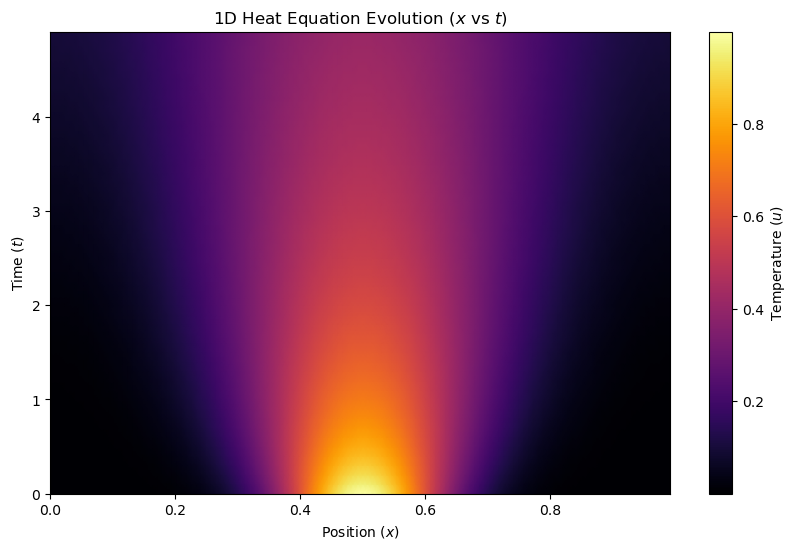

In [6]:
plt.figure(figsize=(10, 6))
plt.pcolormesh(x, time_points, history, shading='gouraud', cmap='inferno')
plt.colorbar(label='Temperature ($u$)')
plt.title('1D Heat Equation Evolution ($x$ vs $t$)')
plt.xlabel('Position ($x$)')
plt.ylabel('Time ($t$)')
plt.show()